# NASDAQ Prediction

In [1]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import sklearn.metrics
import tensorflow as tf
from tensorflow import keras
from keras import layers, metrics
from sklearn.metrics import mean_absolute_error

# Build Dataset

In [2]:
# fetch nasdaq data
nasdaq = yf.Ticker("^IXIC")
data = nasdaq.history(start="2020-01-01", end="2024-12-31", interval="1d")

# drop dividends and stock splits (not used for index)
data.drop(columns=['Stock Splits','Dividends'], inplace=True)

# sanity check
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00-05:00,9039.459961,9093.429688,9010.889648,9092.190430,2862700000
2020-01-03 00:00:00-05:00,8976.429688,9065.759766,8976.429688,9020.769531,2586520000
2020-01-06 00:00:00-05:00,8943.500000,9072.410156,8943.500000,9071.469727,2810450000
2020-01-07 00:00:00-05:00,9076.639648,9091.929688,9042.549805,9068.580078,2381740000
2020-01-08 00:00:00-05:00,9068.030273,9168.889648,9059.379883,9129.240234,2472620000


In [3]:
# make dates match
data.index = data.index.tz_localize(None)

# sanity check
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000


## EDA

In [4]:
# check for NaNs
print(data.isna().sum())

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1257 non-null   float64
 1   High    1257 non-null   float64
 2   Low     1257 non-null   float64
 3   Close   1257 non-null   float64
 4   Volume  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [6]:
data.describe()

,Open,High,Low,Close,Volume
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,13396.866510,13496.945254,13287.901373,13398.897142,4.976232e+09
std,2661.571952,2657.349833,2659.052973,2658.537755,1.204910e+09
min,6847.279785,6984.939941,6631.419922,6860.669922,2.169020e+09
25%,11447.580078,11548.849609,11339.179688,11448.400391,4.308070e+09
50%,13419.870117,13567.139648,13316.519531,13457.250000,4.808710e+09
75%,15028.690430,15114.080078,14939.559570,15047.700195,5.440100e+09
max,20114.980469,20204.580078,20004.730469,20173.890625,1.193260e+10


## Split Data

Since we are working with time series data, there will be no data shuffling.

In [10]:
# Split data by year
train_data = data["2020-01-01":"2022-12-31"] # train data: 2020-2022
val_data = data["2023-01-01":"2023-12-31"] # val data: 2023
test_data = data["2024-01-01":"2024-12-31"] # test data: 2024

# Check shapes
print("Train:", train_data.shape)
print("Validate:", val_data.shape)
print("Test:", test_data.shape)

Train: (756, 6)
Validate: (250, 6)
Test: (251, 6)


In [11]:
train_data.head()

,Open,High,Low,Close,Volume,Daily Return
Date,,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,NaN
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,-0.007855
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,0.005620
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,-0.000319
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,0.006689


In [12]:
val_data.head()

,Open,High,Low,Close,Volume,Daily Return
Date,,,,,,
2023-01-03,10562.059570,10613.059570,10309.160156,10386.980469,4780650000,-0.007596
2023-01-04,10467.820312,10515.219727,10337.639648,10458.759766,5085380000,0.006911
2023-01-05,10390.309570,10393.219727,10295.250000,10305.240234,4764270000,-0.014679
2023-01-06,10363.959961,10604.139648,10265.040039,10569.290039,5199780000,0.025623
2023-01-09,10662.099609,10807.259766,10619.120117,10635.650391,5132190000,0.006279


In [13]:
test_data.head()

,Open,High,Low,Close,Volume,Daily Return
Date,,,,,,
2024-01-02,14873.700195,14887.799805,14682.379883,14765.940430,5791170000,-0.016348
2024-01-03,14641.469727,14694.580078,14577.440430,14592.209961,5449950000,-0.011766
2024-01-04,14532.230469,14632.769531,14504.780273,14510.299805,5289220000,-0.005613
2024-01-05,14500.110352,14625.190430,14477.570312,14524.070312,5232820000,0.000949
2024-01-08,14564.469727,14846.900391,14560.200195,14843.769531,6337770000,0.022012


## Data Prep

In [15]:
# Reset the index column so that Date is not the index
data = data.reset_index()

In [16]:
# Define a function to prepare, scale, and split data
def prepare_data(data, n_steps, input_columns):
    # Split train, val, test data based on date range (Train: 2020-2022, Val: 2023, Test: 2024)
    train_data = data[data['Date'] < '2023-01-01']
    val_data = data[(data['Date'] >= '2023-01-01') & (data['Date'] < '2024-01-01')]
    test_data = data[data['Date'] >= '2024-01-01']
    
    # Store dates for future plotting
    val_dates = val_data['Date'].iloc[n_steps:].values
    test_dates = test_data['Date'].iloc[n_steps:].values
    
    # Initialize scalers for input and output separately
    input_scaler = MinMaxScaler()
    output_scaler = MinMaxScaler()
    
    # Scale the input columns (X) and target column ('Close') separately
    train_inputs = input_scaler.fit_transform(train_data[input_columns])
    train_target = output_scaler.fit_transform(train_data[['Close']])
    
    val_inputs = input_scaler.transform(val_data[input_columns])
    val_target = output_scaler.transform(val_data[['Close']])
    
    test_inputs = input_scaler.transform(test_data[input_columns])
    test_target = output_scaler.transform(test_data[['Close']])
    
    # Time series helper function to create feature sequences where n_steps is the number of previous days to consider for next day's prediction
    def create_sequences(X_data, y_data, n_steps):
        X, y = [], []
        for i in range(len(X_data) - n_steps):
            # Append a sequence of 'n_steps' time steps from X_data to X
            X.append(X_data[i:(i + n_steps)])
            # Append the target value corresponding to the next time step from y_data
            y.append(y_data[i + n_steps])  
        return np.array(X), np.array(y)
    
    X_train, y_train = create_sequences(train_inputs, train_target, n_steps)
    X_val, y_val = create_sequences(val_inputs, val_target, n_steps)
    X_test, y_test = create_sequences(test_inputs, test_target, n_steps)
    
    return train_data, val_data, test_data, X_train, y_train, X_val, y_val, val_dates, X_test, y_test, test_dates, output_scaler

In [17]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily Return'], dtype='object')

In [18]:
data.head()

,Date,Open,High,Low,Close,Volume,Daily Return
0,2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,NaN
1,2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,-0.007855
2,2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,0.005620
3,2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,-0.000319
4,2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,0.006689


In [19]:
# Preparing the data for using all original features & using 90 days historical data for next day's prediction
n_steps = 90
input_columns = ['Open', 'High', 'Low', 'Volume']
train_df, val_df, test_df, X_train, y_train, X_val, y_val, val_dates, X_test, y_test, test_dates, output_scaler = prepare_data(data, n_steps, input_columns)

In [20]:
train_df.head()

,Date,Open,High,Low,Close,Volume,Daily Return
0,2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,NaN
1,2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,-0.007855
2,2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,0.005620
3,2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,-0.000319
4,2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,0.006689


# Model Building

## Helper Functions

In [21]:
# Implement early stopping function to prevent overfitting
early_stopping = EarlyStopping(
    monitor='mae',
    mode='min',
    patience=20,   
    restore_best_weights=True  
)

In [22]:
# Function to plot validation mae
def plot_model_mae(history, model_name):
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(model_name + ' Model Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.show()

In [78]:
# Function to plot predictions
def plot_predictions(dates, actual, predicted, title):
    plt.figure(figsize=(12, 6))
    
    # Plot actual values in gray
    plt.plot(dates, actual, color="gray", label="Actual")
    
    # Plot predicted values in blue
    plt.plot(dates, predicted, color="blue", label="Predicted")
    
    plt.title(f'{title}')
    plt.xlabel("Date")
    plt.ylabel('Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

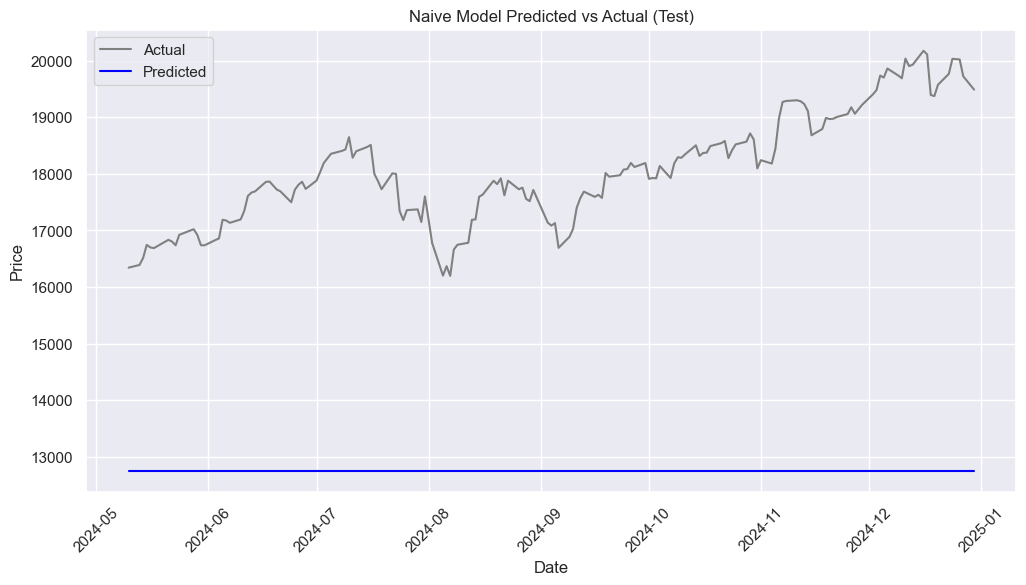

Naive Val MAE in Original Units: 978.3690787283853
Naive Test MAE in Original Units: 5298.171519460793


In [93]:
naive_prediction_test = np.full_like(y_test, np.mean(y_train))
naive_prediction_val = np.full_like(y_val, np.mean(y_train))
plot_predictions(test_dates, output_scaler.inverse_transform(y_test.reshape(-1, 1)), output_scaler.inverse_transform(naive_prediction_test.reshape(-1, 1)), "Naive Model Predicted vs Actual (Test)")

print('Naive Val MAE in Original Units:', mean_absolute_error(output_scaler.inverse_transform(naive_prediction_val), output_scaler.inverse_transform(y_val.reshape(-1, 1))))
print('Naive Test MAE in Original Units:', mean_absolute_error(output_scaler.inverse_transform(naive_prediction_test), output_scaler.inverse_transform(y_test.reshape(-1, 1))))

## Basic LSTM model using all yfinance features

Epoch 1/50


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2472 - mae: 0.2472 - mse: 0.0840 - val_loss: 0.0763 - val_mae: 0.0763 - val_mse: 0.0068
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0589 - mae: 0.0589 - mse: 0.0050 - val_loss: 0.0462 - val_mae: 0.0462 - val_mse: 0.0028
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0390 - mae: 0.0390 - mse: 0.0024 - val_loss: 0.0269 - val_mae: 0.0269 - val_mse: 0.0010
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0331 - mae: 0.0331 - mse: 0.0016 - val_loss: 0.0249 - val_mae: 0.0249 - val_mse: 9.8942e-04
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0316 - mae: 0.0316 - mse: 0.0018 - val_loss: 0.0255 - val_mae: 0.0255 - val_mse: 9.3354e-04
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0311 - mae: 0.0311 - mse: 0.0016 - val_loss: 0.0249 - val_mae: 0.0249 - val_mse: 9.0168e-04
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0304 - mae: 0.0304 - mse: 0.0016 - val_loss:

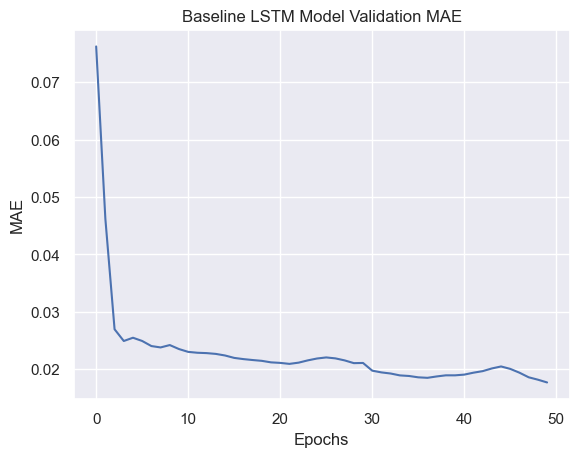

In [24]:
tf.random.set_seed(0)

lstm_model_all_features = tf.keras.Sequential()

lstm_model_all_features.add(tf.keras.layers.LSTM(32, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))

# Output layer
lstm_model_all_features.add(tf.keras.layers.Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_model_all_features.compile(optimizer=optimizer, loss='mae', metrics=['mae', 'mse'])

lstm_all_features_history = lstm_model_all_features.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=1,
        callbacks=[early_stopping])

lstm_train_loss = lstm_all_features_history.history['loss'][-1]
lstm_val_loss, lstm_val_mae, lstm_val_mse = lstm_model_all_features.evaluate(X_val, y_val)
lstm_test_loss, lstm_test_mae, lstm_test_mse = lstm_model_all_features.evaluate(X_test, y_test)
print(f"Training Loss (MAE): {lstm_train_loss}")
print(f"Validation Loss (MAE): {lstm_val_loss}, Validation MAE: {lstm_val_mae}, Validation MSE: {lstm_val_mse}")
print(f"Test Loss (MAE): {lstm_test_loss}, Test MAE: {lstm_test_mae}, Test MSE: {lstm_test_mse}")

plot_model_mae(lstm_all_features_history, 'Baseline LSTM')

In [25]:
lstm_model_all_features.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,309 (55.90 KB)

 Trainable params: 4,769 (18.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,540 (37.27 KB)

In [26]:
# Convert loss values to original units
print("Baseline Validation Loss in Original Units: ", 
      mean_absolute_error(output_scaler.inverse_transform(y_val.reshape(-1, 1)), output_scaler.inverse_transform(lstm_model_all_features.predict(X_val))))
print("Baseline Test Loss in Original Units: ", 
      mean_absolute_error(output_scaler.inverse_transform(y_test.reshape(-1, 1)), output_scaler.inverse_transform(lstm_model_all_features.predict(X_test))))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
Baseline Validation Loss in Original Units:  162.46843261718755
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Baseline Test Loss in Original Units:  228.6226222826087


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


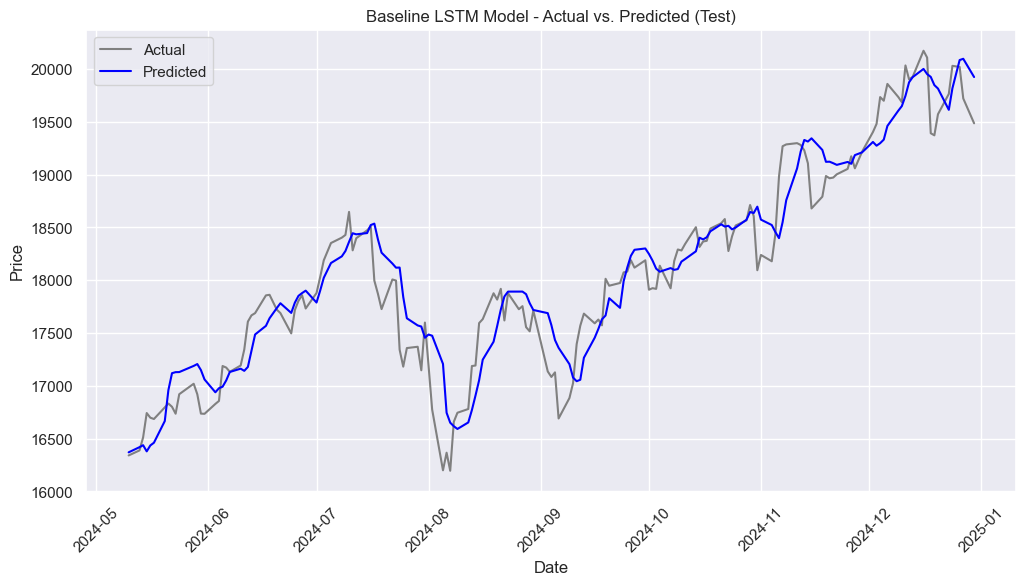

In [27]:
plot_predictions(test_dates, output_scaler.inverse_transform(y_test), output_scaler.inverse_transform(lstm_model_all_features.predict(X_test)), "Baseline LSTM Model - Actual vs. Predicted (Test)")

## Hyperparmeter Tuning w/ only Low High using MAE as loss

In [28]:
# Preparing the data for using all original features & using 90 days historical data for next day's prediction
n_steps = 90
input_columns = ['Low', 'High']
train_df, val_df, test_df, X_train, y_train, X_val, y_val, val_dates, X_test, y_test, test_dates, output_scaler = prepare_data(data, n_steps, input_columns)

In [127]:
tf.keras.backend.clear_session()
tf.random.set_seed(0)

def build_model_tuner(hp):
    """Builds an LSTM model with tunable hyperparameters."""
    model = tf.keras.Sequential()
    
    # Adding 1 LSTM Layer
    model.add(
        tf.keras.layers.LSTM(
            units=hp.Int('LSTMUnits_0', min_value=32, max_value=256, step=32),
            activation='tanh',
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )
        
    # Adding dropout layer after LSTM layer
    dropout_rate = hp.Float('Dropout_0', min_value=0, max_value=0.3, step=0.1)
    
    if dropout_rate > 0:
        model.add(tf.keras.layers.Dropout(rate=dropout_rate))
    
    # Output Layer
    model.add(tf.keras.layers.Dense(1))

    # Tune the learning rate and optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.005, 0.0001])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])

    return model

# Initialize the tuner
tuner = kt.Hyperband(
    build_model_tuner,
    objective='val_mae', 
    max_epochs=200,
    factor=4,
    project_name='lstm_model_hyperband_lowhigh'
)

# Perform the hyperparameter search
tuner.search(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val)
)

Reloading Tuner from ./lstm_model_hyperband_lowhigh/tuner0.json


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 2.7895 - mae: 1.0400 - val_loss: 0.0076 - val_mae: 0.0777
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0249 - mae: 0.1280 - val_loss: 0.0040 - val_mae: 0.0549
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0161 - mae: 0.1061 - val_loss: 0.0119 - val_mae: 0.1034
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0109 - mae: 0.0818 - val_loss: 0.0012 - val_mae: 0.0276
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0062 - mae: 0.0637 - val_loss: 0.0019 - val_mae: 0.0371
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0050 - mae: 0.0563 - val_loss: 0.0017 - val_mae: 0.0353
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0044 - mae: 0.0516 - val_loss: 7.8355e-04 - val_mae: 0.0229
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0040 - mae: 0.0495 - val_loss: 8.5690e-04 - val_mae: 0.0235
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/s

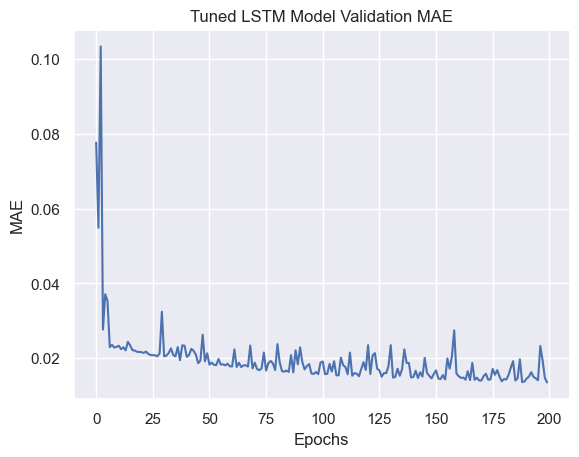

In [133]:
# Get the best hyperparameters
tuned_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the best model
tuned_model = tuner.hypermodel.build(tuned_hps)

# Train the best model
history = tuned_model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), batch_size=64, 
                         callbacks=early_stopping)

# Evaluate the model on validation and test set
train_mae = history.history['loss'][-1]
print(f'Training MAE: {train_mae:.6f}')
val_mse, val_mae = tuned_model.evaluate(X_val, y_val)
print(f'Validation MSE: {val_mse:.6f}, Validation MAE: {val_mae:.6f}')
test_mse, test_mae = tuned_model.evaluate(X_test, y_test)
print(f'Test MSE: {test_mse:.6f}, Test MAE: {test_mae:.6f}')

plot_model_mae(history, 'Tuned LSTM')

In [129]:
# Convert loss values to original units
print("Tuned Validation Loss in Original Units: ", 
      mean_absolute_error(output_scaler.inverse_transform(y_val.reshape(-1, 1)), output_scaler.inverse_transform(tuned_model.predict(X_val))))
print("Tuned Test Loss in Original Units: ", 
      mean_absolute_error(output_scaler.inverse_transform(y_test.reshape(-1, 1)), output_scaler.inverse_transform(tuned_model.predict(X_test))))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Tuned Validation Loss in Original Units:  132.79725952148436
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Tuned Test Loss in Original Units:  223.7647030279504


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


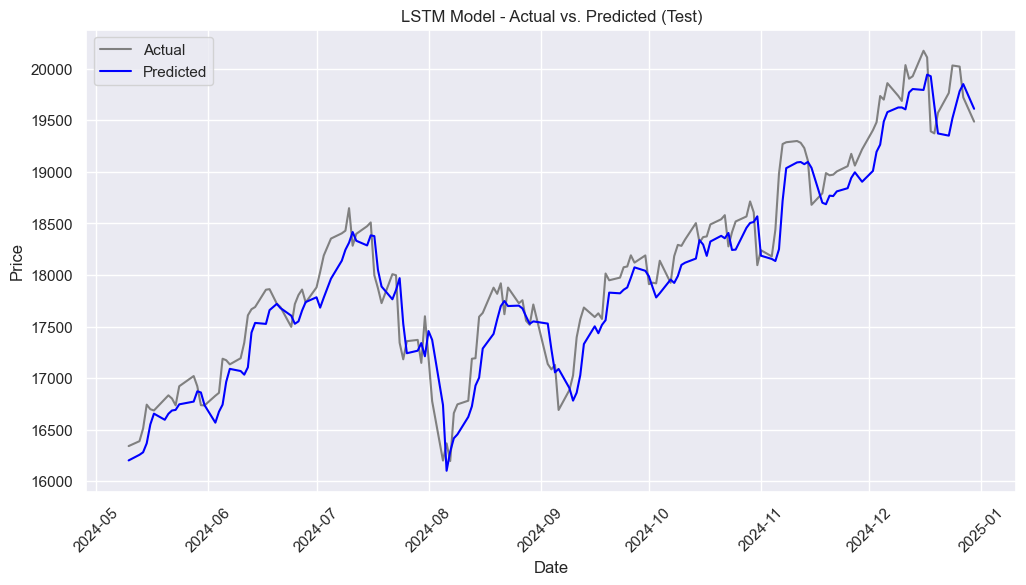

In [130]:
plot_predictions(test_dates, output_scaler.inverse_transform(y_test), output_scaler.inverse_transform(tuned_model.predict(X_test)), "LSTM Model - Actual vs. Predicted (Test)")

# Hyperparameter Analysis

## Summary by Trial

In [134]:
trial_summaries = []

for trial in tuner.oracle.trials.values():
    hp_values = trial.hyperparameters.values.copy()
    hp_values['score'] = trial.score
    hp_values['trial_id'] = trial.trial_id
    trial_summaries.append(hp_values)

results_df = pd.DataFrame(trial_summaries)
results_df = results_df.sort_values(by='score').reset_index(drop=True)

results_df.head(50)

,LSTMUnits_0,Dropout_0,learning_rate,tuner/epochs,tuner/initial_epoch,tuner/bracket,tuner/round,tuner/trial_id,score,trial_id
0,160,0.2,0.010,200,50,3,3,0100,0.011908,0105
1,128,0.1,0.005,200,50,3,3,0104,0.011984,0106
2,160,0.2,0.010,50,13,3,2,0099,0.012621,0100
3,128,0.1,0.005,50,13,3,2,0082,0.012924,0104
4,64,0.1,0.005,50,13,3,2,0089,0.013064,0101
5,256,0.2,0.005,50,13,3,2,0094,0.013157,0103
6,128,0.0,0.010,50,13,3,2,0085,0.014132,0102
7,160,0.2,0.010,13,4,3,1,0073,0.015720,0099
8,64,0.1,0.005,13,4,3,1,0032,0.015757,0089
9,128,0.0,0.010,13,4,3,1,0037,0.015891,0085


## Neurons

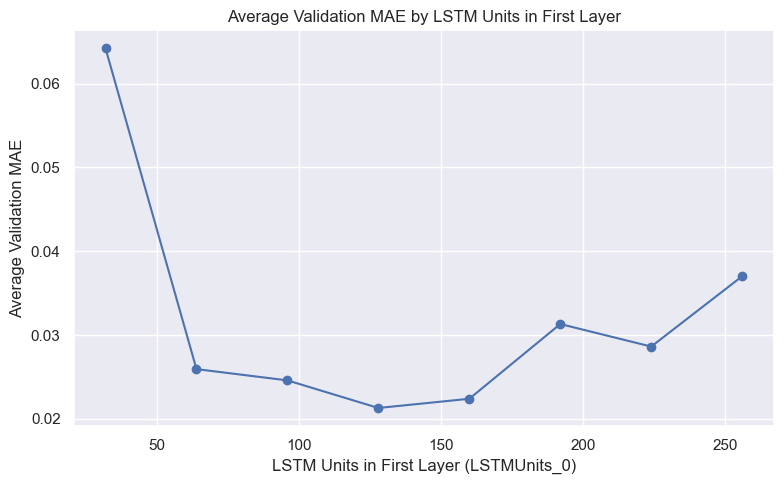

In [135]:
# Group by LSTMUnits_0 and calculate the average score
avg_scores = results_df.groupby('LSTMUnits_0')['score'].mean().reset_index()

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(avg_scores['LSTMUnits_0'], avg_scores['score'], marker='o', linestyle='-')
plt.xlabel('LSTM Units in First Layer (LSTMUnits_0)')
plt.ylabel('Average Validation MAE')
plt.title('Average Validation MAE by LSTM Units in First Layer')
plt.grid(True)
plt.tight_layout()
plt.show()

## Learning Rate

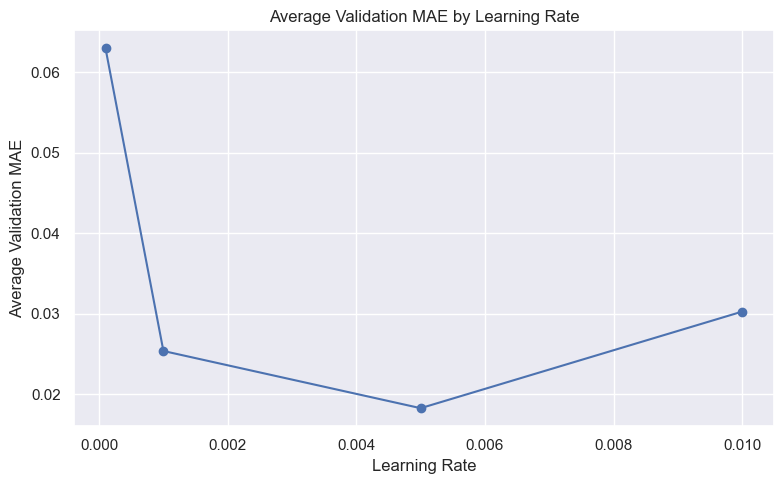

In [136]:
# Group by learning_rate
avg_lr_scores = results_df.groupby('learning_rate')['score'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_lr_scores['learning_rate'], avg_lr_scores['score'], marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Average Validation MAE')
plt.title('Average Validation MAE by Learning Rate')
plt.grid(True)
plt.tight_layout()
plt.show()

## Dropout Rate

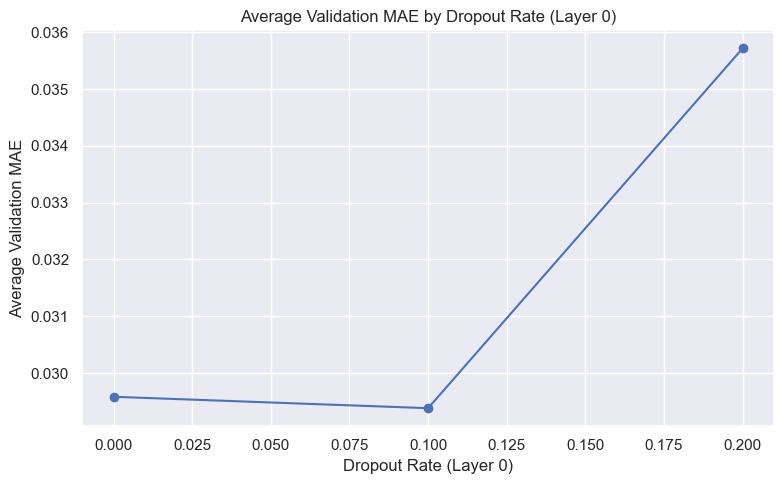

In [137]:
# Group by Dropout_0
avg_dropout_scores = results_df.groupby('Dropout_0')['score'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_dropout_scores['Dropout_0'], avg_dropout_scores['score'], marker='o')
plt.xlabel('Dropout Rate (Layer 0)')
plt.ylabel('Average Validation MAE')
plt.title('Average Validation MAE by Dropout Rate (Layer 0)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
# Rerun tuner with 0 dropout based on findings above
tf.keras.backend.clear_session()
tf.random.set_seed(0)

def build_model_tuner(hp):
    """Builds an LSTM model with tunable hyperparameters."""
    model = tf.keras.Sequential()
    
    # Adding 1 LSTM Layer
    model.add(
        tf.keras.layers.LSTM(
            units=hp.Int('LSTMUnits_0', min_value=32, max_value=256, step=32),
            activation='tanh',
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )
    
    # Output Layer
    model.add(tf.keras.layers.Dense(1))

    # Tune the learning rate and optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.005, 0.0001])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])

    return model

# Initialize the tuner
tuner = kt.Hyperband(
    build_model_tuner,
    objective='val_mae', 
    max_epochs=200,
    factor=4,
    project_name='lstm_model_hyperband_lowhigh_0dropout'
)

# Perform the hyperparameter search
tuner.search(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val)
)

Trial 30 Complete [00h 00m 14s]
val_mae: 0.020851578563451767

Best val_mae So Far: 0.019070938229560852
Total elapsed time: 00h 05m 03s


In [77]:
tuner.results_summary(num_trials=3)

Results summary
Results in ./lstm_model_hyperband_lowhigh_0dropout
Showing 3 best trials
Objective(name="val_mae", direction="min")

Trial 0021 summary
Hyperparameters:
LSTMUnits_0: 160
learning_rate: 0.005
tuner/epochs: 4
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0
Score: 0.019070938229560852

Trial 0027 summary
Hyperparameters:
LSTMUnits_0: 192
learning_rate: 0.005
tuner/epochs: 4
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0
Score: 0.01956617459654808

Trial 0016 summary
Hyperparameters:
LSTMUnits_0: 128
learning_rate: 0.01
tuner/epochs: 4
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0
Score: 0.01996474340558052


Epoch 1/200


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.1931 - mae: 0.3484 - val_loss: 0.0154 - val_mae: 0.1210
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0108 - mae: 0.0861 - val_loss: 0.0024 - val_mae: 0.0416
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0060 - mae: 0.0645 - val_loss: 0.0039 - val_mae: 0.0568
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0029 - mae: 0.0447 - val_loss: 0.0012 - val_mae: 0.0290
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0020 - mae: 0.0371 - val_loss: 5.7283e-04 - val_mae: 0.0194
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0015 - mae: 0.0311 - val_loss: 5.3590e-04 - val_mae: 0.0188
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0012 - mae: 0.0272 - val_loss: 5.3820e-04 - val_mae: 0.0188
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0011 - mae: 0.0254 - val_loss: 5.9539e-04 - val_mae: 0.0197
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step

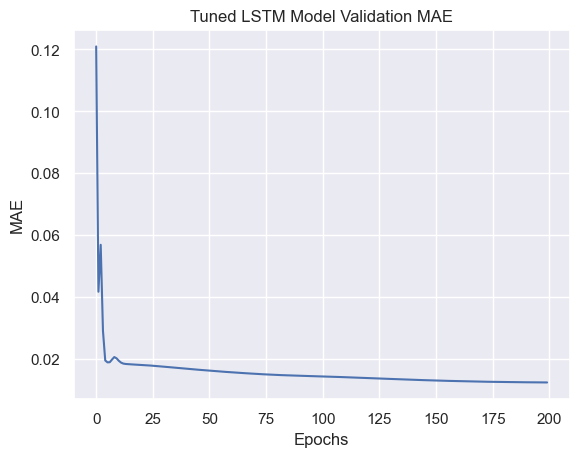

In [95]:
# Get the best hyperparameters
def build_tuned_model():
    tuned_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Build the best model
    tuned_model = tuner.hypermodel.build(tuned_hps)

    # Train the best model
    history = tuned_model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), batch_size=64, 
                            callbacks=early_stopping)
    
    return tuned_model, history

tuned_model, history = build_tuned_model()

# Evaluate the model on validation and test set
train_mae = history.history['loss'][-1]
print(f'Training MAE: {train_mae:.6f}')
val_mse, val_mae = tuned_model.evaluate(X_val, y_val)
print(f'Validation MSE: {val_mse:.6f}, Validation MAE: {val_mae:.6f}')
test_mse, test_mae = tuned_model.evaluate(X_test, y_test)
print(f'Test MSE: {test_mse:.6f}, Test MAE: {test_mae:.6f}')

plot_model_mae(history, 'Tuned LSTM')

In [96]:
# Convert loss values to original units
print("Tuned Validation Loss in Original Units: ", 
      mean_absolute_error(output_scaler.inverse_transform(y_val.reshape(-1, 1)), output_scaler.inverse_transform(tuned_model.predict(X_val))))
print("Tuned Test Loss in Original Units: ", 
      mean_absolute_error(output_scaler.inverse_transform(y_test.reshape(-1, 1)), output_scaler.inverse_transform(tuned_model.predict(X_test))))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Tuned Validation Loss in Original Units:  113.11259155273441
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Tuned Test Loss in Original Units:  159.78278459821425


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


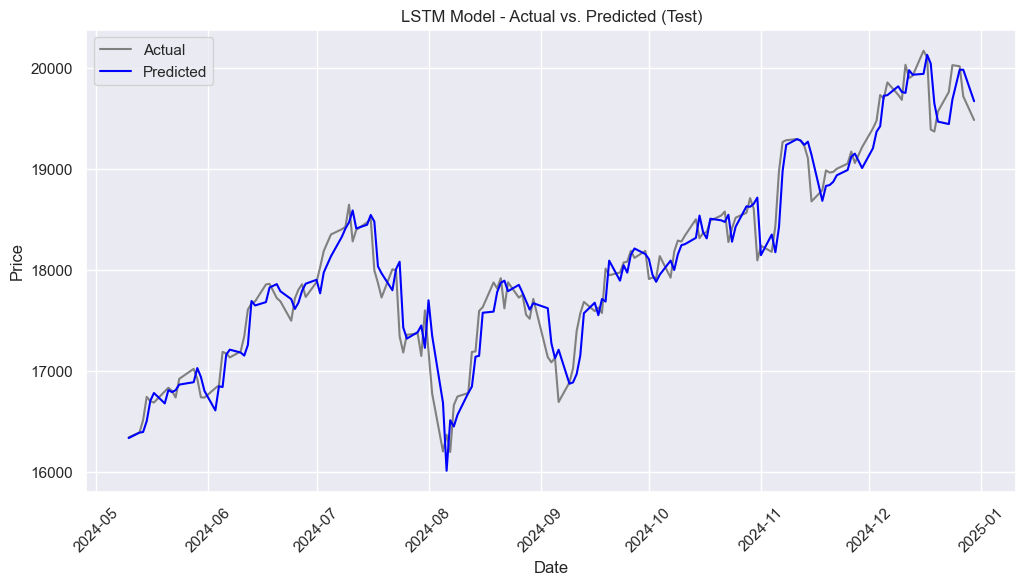

In [97]:
plot_predictions(test_dates, output_scaler.inverse_transform(y_test), output_scaler.inverse_transform(tuned_model.predict(X_test)), "LSTM Model - Actual vs. Predicted (Test)")

### Experiment over 10 Iterations, Error Bars

In [98]:
num_runs = 10
val_mae_scores = []
test_mae_scores = []

for i in range(num_runs):
    tf.keras.backend.clear_session()
    
    tuned_model, history = build_tuned_model()
    
    # Evaluate on validation and test
    val_preds = tuned_model.predict(X_val)
    test_preds = tuned_model.predict(X_test)

    val_mae = mean_absolute_error(y_val, val_preds)
    test_mae = mean_absolute_error(y_test, test_preds)

    val_mae_scores.append(val_mae)
    test_mae_scores.append(test_mae)

Epoch 1/200


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.1413 - mae: 0.3108 - val_loss: 0.0055 - val_mae: 0.0689
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0070 - mae: 0.0661 - val_loss: 0.0018 - val_mae: 0.0349
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0032 - mae: 0.0469 - val_loss: 8.2029e-04 - val_mae: 0.0227
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0024 - mae: 0.0397 - val_loss: 7.9884e-04 - val_mae: 0.0234
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0014 - mae: 0.0299 - val_loss: 7.3783e-04 - val_mae: 0.0226
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0011 - mae: 0.0259 - val_loss: 5.6048e-04 - val_mae: 0.0193
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 9.8724e-04 - mae: 0.0247 - val_loss: 5.5358e-04 - val_mae: 0.0190
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0010 - mae: 0.0248 - val_loss: 5.8318e-04 - val_mae: 0.0195
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.1167 - mae: 0.2171 - val_loss: 9.8393e-04 - val_mae: 0.0248
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0028 - mae: 0.0433 - val_loss: 0.0013 - val_mae: 0.0295
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0017 - mae: 0.0334 - val_loss: 6.4838e-04 - val_mae: 0.0212
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0011 - mae: 0.0264 - val_loss: 7.3926e-04 - val_mae: 0.0227
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 9.6097e-04 - mae: 0.0247 - val_loss: 4.9635e-04 - val_mae: 0.0182
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0010 - mae: 0.0248 - val_loss: 5.5129e-04 - val_mae: 0.0194
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 9.3057e-04 - mae: 0.0242 - val_loss: 4.7452e-04 - val_mae: 0.0177
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 9.5950e-04 - mae: 0.0243 - val_loss: 4.9907e-04 - val_mae: 0.0184
Epoch 9/200
11/11 ━━━━━━━━

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.1287 - mae: 0.2149 - val_loss: 0.0041 - val_mae: 0.0594
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0021 - mae: 0.0366 - val_loss: 5.6716e-04 - val_mae: 0.0196
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0011 - mae: 0.0261 - val_loss: 0.0013 - val_mae: 0.0299
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0017 - mae: 0.0326 - val_loss: 0.0018 - val_mae: 0.0366
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0021 - mae: 0.0367 - val_loss: 7.7706e-04 - val_mae: 0.0234
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0012 - mae: 0.0280 - val_loss: 5.4889e-04 - val_mae: 0.0194
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 9.6614e-04 - mae: 0.0249 - val_loss: 4.9701e-04 - val_mae: 0.0181
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0011 - mae: 0.0263 - val_loss: 5.0134e-04 - val_mae: 0.0184
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.1245 - mae: 0.2253 - val_loss: 5.8018e-04 - val_mae: 0.0198
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0024 - mae: 0.0391 - val_loss: 0.0017 - val_mae: 0.0356
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0019 - mae: 0.0363 - val_loss: 6.4513e-04 - val_mae: 0.0203
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0012 - mae: 0.0268 - val_loss: 5.8075e-04 - val_mae: 0.0201
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 9.1984e-04 - mae: 0.0244 - val_loss: 5.2813e-04 - val_mae: 0.0190
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 9.1073e-04 - mae: 0.0239 - val_loss: 4.6379e-04 - val_mae: 0.0175
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 9.3587e-04 - mae: 0.0240 - val_loss: 4.8838e-04 - val_mae: 0.0182
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 8.9525e-04 - mae: 0.0237 - val_loss: 4.5608e-04 - val_mae: 0.0174
Epoch 9/200
11/11 ━━━━━

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.1760 - mae: 0.2751 - val_loss: 0.0095 - val_mae: 0.0936
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0053 - mae: 0.0587 - val_loss: 0.0028 - val_mae: 0.0478
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0024 - mae: 0.0395 - val_loss: 8.9854e-04 - val_mae: 0.0250
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0013 - mae: 0.0300 - val_loss: 5.8476e-04 - val_mae: 0.0199
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0010 - mae: 0.0254 - val_loss: 5.3324e-04 - val_mae: 0.0189
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 9.3905e-04 - mae: 0.0243 - val_loss: 5.1495e-04 - val_mae: 0.0185
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 9.5327e-04 - mae: 0.0243 - val_loss: 5.0900e-04 - val_mae: 0.0183
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 9.5563e-04 - mae: 0.0243 - val_loss: 5.0922e-04 - val_mae: 0.0184
Epoch 9/200
11/11 ━━━━━━━━━━━━━

In [100]:
val_mae_scores, test_mae_scores

([0.012205629855953005,
  0.017709431685084237,
  0.01216949797896668,
  0.012304489261435016,
  0.012223198080014085,
  0.01215343715201775,
  0.011990019672912185,
  0.012008454405211507,
  0.017384796796758018,
  0.012122356273674069],
 [0.01733126659285028,
  0.026915060720911044,
  0.017700290081505816,
  0.017438370432260687,
  0.01736698228651552,
  0.017765435489360125,
  0.017403965629538574,
  0.020053091856111125,
  0.02515027168171596,
  0.017259796007841496])

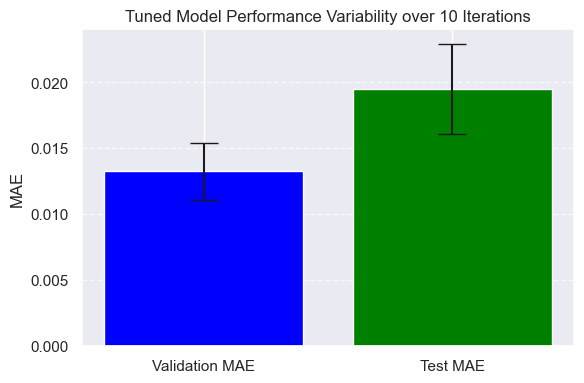

In [113]:
val_mean, test_mean = np.mean(val_mae_scores), np.mean(test_mae_scores)
val_std, test_std = np.std(val_mae_scores), np.std(test_mae_scores)

plt.figure(figsize=(6, 4))
plt.bar(['Validation MAE', 'Test MAE'], [val_mean, test_mean], yerr=[val_std, test_std], capsize=10, color=['blue', 'green'])
plt.ylabel('MAE')
plt.title('Tuned Model Performance Variability over 10 Iterations')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [119]:
print('Validation MAE Mean:', round(val_mean, 3)
print('Validation MAE Mean:', round(test_mean, 3)
print('Validation MAE STD:', round(val_std, 4)
print('Test MAE STD:', round(test_std, 4)

Validation MAE Mean: [0.013]
Test MAE Mean: [0.019]
Validation MAE STD: [0.0023]
Test MAE STD: [0.0036]
